# **Geophysics Lab 4: Seismic Reflection**
Name: Firstname Lastname

**If you don't put your name in both the spot above AND the filename, you will not receive a grade for this lab.** Double-click this cell to add your name, run the cell when you're done. In the filename, please **do not** put any spaces between words or wildcard characters. I will not be grading labs in different file formats or with spaces/wildcards in the file names.

In [ ]:
# run this cell to import some of the packages needed to complete this lab:
import numpy as np               # more on numpy here:       https://numpy.org/doc/stable/user/absolute_beginners.html
import matplotlib.pyplot as plt  # more on matplotlib here:  https://matplotlib.org/stable/users/explain/quick_start.html

This lab will require you to import the data file `SubductionData.txt` and use it in Section 3. **Please make sure that you have downloaded the data file and put it into the same folder as this lab** (if the file path is not correct in your notebook, I will get an error when I run your code, and you will not get credit for the relevant questions).

In [ ]:
# we are importing some other packages 'early' to see if you will have any issues with imports in this lab:
import pandas as pd              # more on pandas here:    https://pandas.pydata.org/docs/
from pyrocko import cake         # more on pyrocko here:   https://pyrocko.org/docs/current/index.html

# if this cell returns an error, you might not have the necessary packages installed. 
# if you can't figure out the installation, please contact your TA ASAP!

This lab consists of 3 sections, and each section has problems for you to solve throughout. <span style="background-color: pink;">**Make sure to read and address all parts of each question.**</span>

## Section 1: Plotting travel time curves for reflected waves
From Lab 3: "Imagine a source at the surface located 10 m from the first receiver, or geophone, in a 10-geophone line. The spacing between geophones is 10 m. We also know that the thickness of the layer closest to the surface is 20 m."

We use the same code from lab 3 that defines a layered model, with one homogeneous layer that is 20 meters thick. The $V_p$ of layer1 is `2000 (m/s)`. **We still won't use S-wave phases during this lab.**

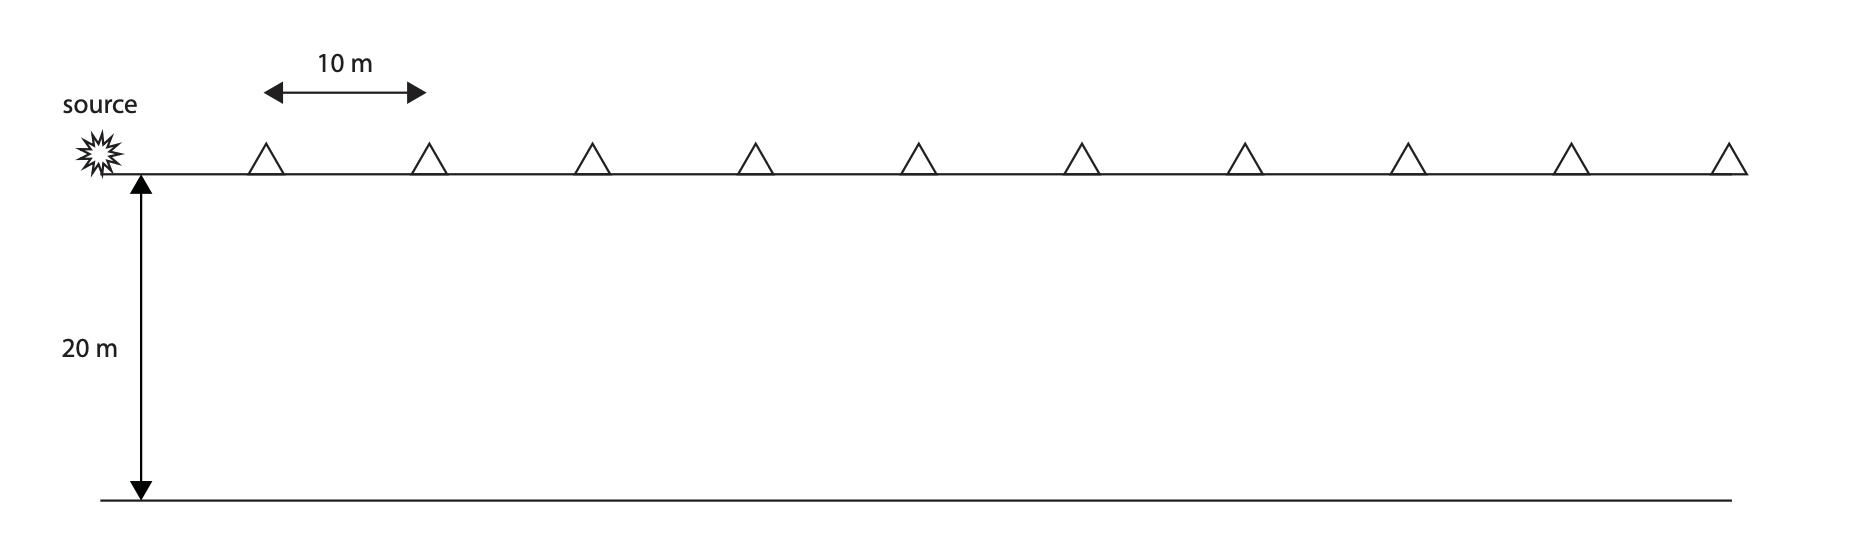

In [ ]:
m_layer1 = cake.Material(vp=2000.)
m_layer2 = cake.Material(vp=4000.)

model = cake.LayeredModel()
model.append(cake.Surface(z=0., mbelow=m_layer1))
model.append(cake.HomogeneousLayer(0., 20., m_layer1, name='layer1'))
model.append(cake.Interface(z=20., mabove=m_layer1, mbelow=m_layer2, name="interface1"))

Similar to lab 3, we define the source to be sightly below the surface, and receivers arranges at 10, 20, 30, ... 100 meters.

In [ ]:
source_depth = 0.01                               # source depth [m]
distances    = np.arange(10, 101, 10) * cake.m2d  # convert distance in meters to degrees

Here we define the phase that we calculate the travel time. There is a subtle difference in the phase defined. Remember that in lab 3 we define the refraction wave along interface 1 as `Pv_(interface1)p`. Here, for the reflection wave, there is no `_` (underscore), indicating that the phase bounds back immediately after touching the interface, making it the reflection.

In [ ]:
phase = cake.PhaseDef('Pv(interface1)p') # see the lack of underscore?

In [ ]:
# save the travel-time:
x_reflect_cake = [];
t_reflect_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    print('%13g %13g' % (arrival.x*cake.d2m, arrival.t))
    x_reflect_cake.append(arrival.x*cake.d2m)
    t_reflect_cake.append(arrival.t)

**Question 1.1:** \
Notice that this is the same subsurface configuration as in the refraction lab. **Copy and paste your code that made your plot in _Lab 3, Problem 1.2_ into the cell below.** Once you've done that, **add the travel time curve for the reflected wave to your plot** – this should only require a line or two added to your previous code. Make sure to label axes and add a legend. (Your solution to this should come in the form of a plot with three curves on it.) _(2 points)_

In [ ]:
# put your code here to address question 1.1

**Question 1.2:** \
Now, copy-paste your code from your solution to 1.1. Make the geophone spacing 20 m instead of 10 m and rerun it-- take a look at how we defined the problem when you do this! (Your solution to this should come in the form of a plot with three curves on it.) Make sure your axes are labeled and you have a legend. _(1 point)_

In [ ]:
# your code (copy-pasted from 1.1, with the geophone spacing changed) here to address question 1.2

Notice that as distance from the shot increases, the arrival times of the direct wave and the reflected wave get closer together. Think about this in terms of a triangle formed by the half of the surface distance from the shot to the geophone (x), the thickness of the layer (h), and the ray path to the boundary layer (r). The layer thickness is constant but increasing the value of x also changes the length of r and the angle of incidence.

**Question 1.3:** \
Explain why the arrival times of the reflected wave approach that of the direct wave, using the diagram above as a template. Clearly reference the ray paths of both direct and reflected waves from the diagram above in your explanation. _(1 point)_

_Double-click this cell and replace this text with your answers to Question 1.3. Run the cell when you're done._

**Question 1.4:** \
Explain why travel times of the critically refracted wave are similar to the reflected wave on geophones closer to the shot, but arrive earlier than reflected waves for geophones further from the shot. Again, explain this with clear references to your two plots in a paragraph similar to the one above. Think about the relative distances each ray travels in each material. _(1 point)_

_Double-click this cell and replace this text with your answers to Question 1.4. Run the cell when you're done._

## Section 2: Time-distance curves with cake

**Question 2.1:** \
We create a new 3-layer model, each layer is 50 meters thick. Let $V_1$ = 1000 m/s, $V_2$ = 2000 m/s, and $V_3$ = 4000 m/s. Use 50 geophones with 10 meter spacing. Fill in the cake model below and calcuate the travel time. Plot the reflection wave from each interface. Make sure your plot resembles the shape of the one below. _(2 points)_

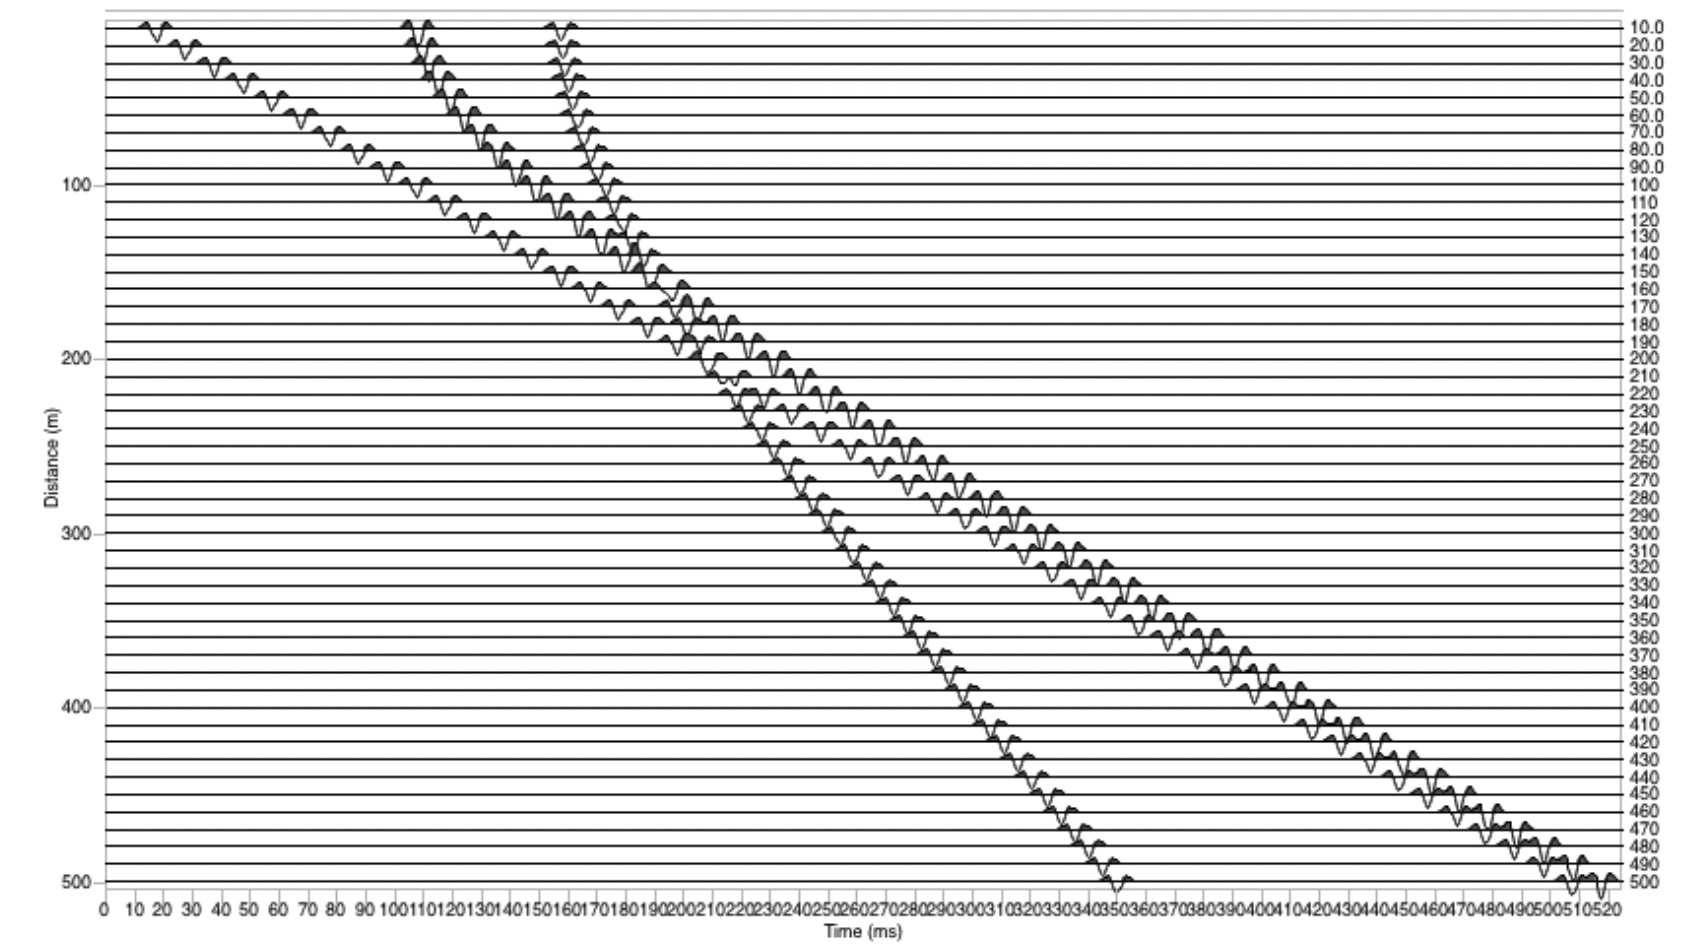

In [ ]:
# Below is a prompt for your solution. Type your solutions here, replace "..." with your code
m_layer1 = cake.Material(vp = ...)
m_layer2 = cake.Material(vp = ...)
m_layer3 = cake.Material(vp = ...)
m_layer4 = cake.Material(vp = ...) # does this matter?

model = cake.LayeredModel()
model.append(cake.Surface(z=0., mbelow=m_layer1))
model.append(cake.HomogeneousLayer(0., ..., m_layer1, name='layer1'))
model.append(cake.Interface(z=..., mabove=m_layer1, mbelow=m_layer2, name="interface1"))
model.append(cake.HomogeneousLayer(..., ..., m_layer2, name='layer2'))
model.append(cake.Interface(z=..., mabove=m_layer2, mbelow=m_layer3, name="interface2"))
model.append(cake.HomogeneousLayer(..., ..., m_layer3, name='layer3'))
model.append(cake.Interface(z=..., mabove=m_layer3, mbelow=m_layer4, name="interface3"))
print(model)

In [ ]:
source_depth = 0.01                               # source depth [m]
distances    = np.arange(10, 501, 10) * cake.m2d  # convert meter to degree

In [ ]:
# We calculate the travel time of reflection wave of each interface, separately.

####### reflection of interface 1
phase = cake.PhaseDef('Pv(interface1)p')
x1_cake = [];
t1_reflect_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    x1_cake.append(arrival.x*cake.d2m)
    t1_reflect_cake.append(arrival.t)

####### reflection of interface 2
phase = cake.PhaseDef('Pv(interface2)p')
x2_cake = [];
t2_reflect_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    x2_cake.append(arrival.x*cake.d2m)
    t2_reflect_cake.append(arrival.t)

####### reflection of interface 3
phase = cake.PhaseDef('Pv(interface3)p')
x3_cake = [];
t3_reflect_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    x3_cake.append(arrival.x*cake.d2m)
    t3_reflect_cake.append(arrival.t)

In [ ]:
# your code to create the plot here to address question 2.1
# remember to label your axes (see the reference plot above) and include a legend
# NB: a time-distance curve plot isn't going to be the same shape (or have the same axes) as your previous travel time plots
plt.figure(figsize=(10, 6), dpi = 100)
plt.figure()
plt.plot(...,...)
...
...
plt.gca().invert_yaxis()
plt.grid()
plt.show();

**Question 2.2:** \
Answer the questions below. _(2 points)_

1. For the plot above, indicate the layer off which each reflected wave bounces (use your legend from 2.1 and look at the provided reference plot).
2. On geophones far away from the shot, why does the second reflected wave arrive before the wave reflected off the first layer? 

**For the questions below, remember that if you change the thickness of the first layer, you need to change the depth of layers and interfaces below.**

3. If we decrease the thickness of layer 1 to 20 m, how does this affect the arrival times of the first reflected wave? (Try it.) Why?
4. Change the thickness of the first layer back to 50 m and decrease the thickness of the middle layer to 10 m. How does this affect the arrivals of the second reflected wave? Why?

_Double-click this cell and replace this text with your answers to Question 2.2. Run the cell when you're done._

**Question 2.3:** \
The basic reflection travel-time equation for a single layer is similar to the equation of a hyperbola:
\begin{equation}
\tag{2.1}
t = \dfrac{\sqrt{x^2+4h_1^2}}{V_1}
\end{equation}

To simplify analysis, square both sides of equation 2.1 and write it in the form of an equation for a straight line. This is called the $x^2-t^2$ method.

Rewrite the reflection travel-time equation in linear form $y=mx +b$ by squaring both sides, expressing $t^2$ as a linear function of $𝑥^2$. Don't worry about rendering it like the equation above. **Show your work.** _(2 points)_

_Double-click this cell and replace this text with your answers to Question 2.3. Run the cell when you're done._

**Question 2.4:** \
Calculating the travel time of waves reflected at deeper layers is complicated because those waves are refracted at shallower boundaries. One way to deal with this complication is Green’s Method, which assumes straight-line paths through all boundaries and solves for velocities and thicknesses. This method is illustrated in the figure below. _(2 points)_

1. Draw the actual ray paths of the reflected waves on the diagram for each ray path. You can draw this on a piece of paper (there will be printed copies in lab) or by editing a screenshot. Submit this to Canvas with your assignment named `lab4_sol24_FirstnameLastname.png`. Put your name in the designated spot.
2. Use your plot to explain below why Green’s Method may not be the most accurate approximation.

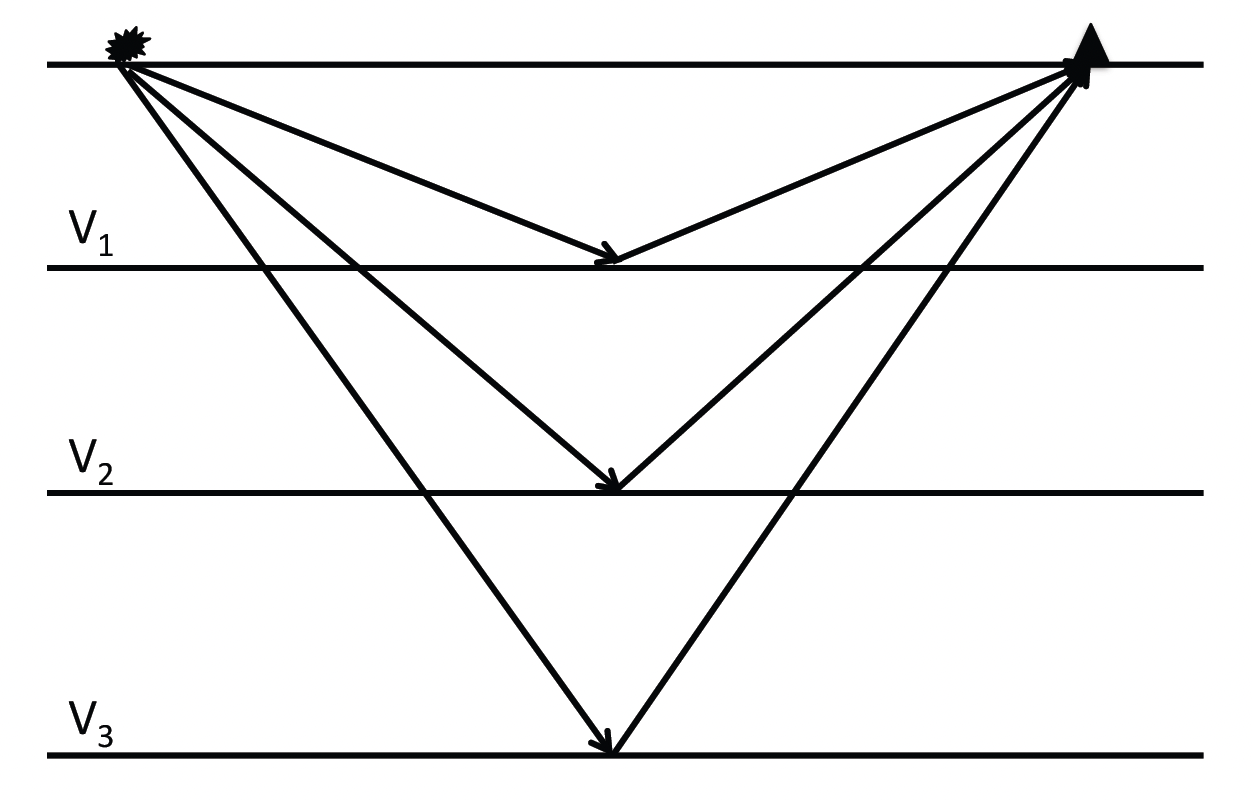

_Double-click this cell and replace this text to address the second part of Question 2.4 here. Run the cell when your're done._

Another way to solve velocities and thicknesses is to use the Dix equation, which uses the root-mean-square velocity ($V_{rms}$). This was (hopefully) covered in lecture.

## Section 3: Modeling the Cascadia Subduction Zone
The Cascadia Subduction Zone (CSZ), where the Juan De Fuca plate dives beneath the North American plate, runs from northern California to Vancouver Island in Canada. This subduction zone is capable of generating large (>M9.0) earthquakes. Since these earthquakes pose a serious threat to cities and towns along the West Coast, we want to learn as much as we can about the CSZ. Shallower earthquakes can cause much more damage than a deep earthquake of the same  size, so determining the depth of the plate interface, where megathrust earthquakes occur, is important. 

In an attempt to figure out the depth of the plate interface, a set of 50 geophones spaced 1000 meters apart was set up on the Olympic Peninsula in an east-west trending line. A seismic reflection study recorded P-wave arrivals; the data is in the `SubductionData.txt` file. **If you have not already downloaded the data file and put it into the same directory as this notebook, please do so now.**

Here, we load the data using the package called pandas (short name as `pd`).

In [ ]:
df = pd.read_csv("./SubductionData.txt", skiprows=3, names=['RecID', 'x', 't1', 't2', 't3'])
df.head() # this function shows the first several rows of the table

In [ ]:
# again, let's define the source and receiver locations: 
source_depth = 0.01                               # source depth [m]
distances    = np.linspace(0, 49000) * cake.m2d   # convert meter to degree

We'll plot the data from this experiment. Let's make it look nice with scatter points. We use `plt.scatter` here since we only have limited and sparse observation from the experiment.

In [ ]:
plt.figure(figsize=(10, 6), dpi=300)
plt.scatter(df['x'], df['t1'], s=40, label="t1", marker='x', zorder=10)
plt.scatter(df['x'], df['t2'], s=40, label="t2", marker='x', zorder=10)
plt.scatter(df['x'], df['t3'], s=40, label="t3", marker='x', zorder=10)
plt.grid()
plt.legend(fontsize=14)
plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Time (s)", fontsize=12)
plt.show();

**Question 3.1:** \
How many layers does this reflection study show, judging by the number of reflections? Put your answer as an integer in the variable below. _(1 point)_

In [ ]:
answer_31 = ... # type your answer here, replace "..." with your answer
answer_31

**Question 3.2:** \
_(6 points)_
1. To analyze these data, we will need to plot the data on an $x^2-t^2$ plot. Modify the code below to show data in $x^2-t^2$ space.

2. Define a cake model to calculate the travel time of the reflected wave off the first interface. It is OK to start with an one-layer model. But note that we don't know the P-wave velocity of the layer, so we need to guess. Here I give you an inital guess of `Vp = 3000 m/s` and `15 km` depth. After you have the travel time of this reflection wave (from your guessed model), add it to the plot below as a dashed line `--`.

3. Does the line fit the observation in terms of the intercept and the slope? What does this suggest about our initial guess of the model?

4. Based on equation 2.1, if you move the line for layer 1 up without changing the slope, do you expect the thickness or velocity of your model to change? Why?

5. Based on equation 2.1, describe how you think changing the slope of the line for layer 1 will affect the thickness or velocity of the layer.

6. Based on your answer to the previous three points in this question, change the parameter of layer 1 (velocity and depth) until it fits the data. It does not need to be perfectly match. 

**Answer 3.2** \
_Double-click this cell and replace this text to address rest of Question 3.2 here. Make sure to address each part of the question. Run the cell when you're done._

In [ ]:
m_layer1 = cake.Material(vp = 3000.)     # layer 1 P-wave velocity
m_layer2 = cake.Material(vp = 9999.)     # layer 2 P-wave velocity
m_layer3 = cake.Material(vp = 9999.)     # layer 3 P-wave velocity
m_layer4 = cake.Material(vp = 9999.)     # layer 4 P-wave velocity

d_interface1 = 15000.                    # interface 1 depth in meter
d_interface2 = 99999.                    # interface 2 depth in meter
d_interface3 = 99999.                    # interface 3 depth in meter

########## Change the parameters above ##########

########## Don't change the code below ##########
model = cake.LayeredModel()
model.append(cake.Surface(z = 0., mbelow = m_layer1))
model.append(cake.HomogeneousLayer(0., d_interface1, m_layer1, name='layer1'))
model.append(cake.Interface(z = d_interface1, mabove = m_layer1, mbelow = m_layer2, name = "interface1"))
model.append(cake.HomogeneousLayer(d_interface1, d_interface2, m_layer2, name='layer2'))
model.append(cake.Interface(z = d_interface2, mabove = m_layer2, mbelow = m_layer3, name = "interface2"))
model.append(cake.HomogeneousLayer(d_interface2, d_interface3, m_layer3, name='layer3'))
model.append(cake.Interface(z = d_interface3, mabove = m_layer3, mbelow = m_layer4, name = "interface3"))

phase = cake.PhaseDef('Pv(interface1)p')
x1_cake = [];
t1_reflect_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    x1_cake.append(arrival.x*cake.d2m)
    t1_reflect_cake.append(arrival.t)
x1_cake = np.array(x1_cake)
t1_reflect_cake = np.array(t1_reflect_cake)

phase = cake.PhaseDef('Pv(interface2)p')
x2_cake = [];
t2_reflect_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    x2_cake.append(arrival.x*cake.d2m)
    t2_reflect_cake.append(arrival.t)
x2_cake = np.array(x2_cake)
t2_reflect_cake = np.array(t2_reflect_cake)

phase = cake.PhaseDef('Pv(interface3)p')
x3_cake = [];
t3_reflect_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    x3_cake.append(arrival.x*cake.d2m)
    t3_reflect_cake.append(arrival.t)
x3_cake = np.array(x3_cake)
t3_reflect_cake = np.array(t3_reflect_cake)

In [ ]:
# Type your answer here, replace "..." with your code
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(..., ..., s=40, label="t1", marker='x', zorder=10)
plt.scatter(..., ..., s=40, label="t2", marker='x', zorder=10)
plt.scatter(..., ..., s=40, label="t3", marker='x', zorder=10)

plt.plot(..., ..., '--', label='t1_cake')
plt.plot(..., ..., '--', label='t2_cake')
plt.plot(..., ..., '--', label='t3_cake')

plt.grid()
plt.legend(fontsize=14, loc = 'upper left')
plt.xlabel("Distance^2 (m^2)", fontsize=12)
plt.ylabel("Time^2 (s^2)", fontsize=12)
plt.show();

**Question 3.3:** \
Keep working on the plot above. _(3 points)_

1. Once you are happy with the parameter of the first layer (depth and vp), let's work on fitting the second layer. Add the second layer reflection as dashed line to your plot above.

2. Change the parameter of the second layer in various ways. Note that changing the line for the first layer changes the whole model, but that is not the case for the second layer. Explain why this is the case.

3. Change the parameter of the second layer reflection until it matches the data.

_Double-click this cell and replace this text with your answers to the second point of Question 3.3. Run the cell when you're done._

**Question 3.4:** \
Keep working on the plot above. Once you are happy with the parameters of the first and the second layer (depth and vp), let's work on fitting the third layer. Add the third layer reflection as dashed line on your plot above. Change the parameter of the third layer reflection until it matches the data. _(2 points)_

**Question 3.5:** \
Based on your final model, discuss the section below (where each layer is labeled with its velocity), **indicating at what depth you think the plate interface is.** 

Make sure you read and address ALL parts of this question. Write a paragraph or two about the validity of the cross section below, using the points below to develop your discussion and referencing your diagram and its labels. Use complete sentences and correct grammar.  _(3 points)_

1. Keep in mind that both the upper plate and the lower plate have a crust and subsequent mantle beneath, so think about which layer is which using the typical mantle P-wave velocity around 8 km/s.

2. What, if anything, can you say about the velocity of the deepest layer based on reflection data alone?

3. Use the table below to determine what types of rocks that make up the crusts of the upper and lower plates. Make sure your interpretation makes sense given that crust of the lower plate is oceanic and the crust of the upper plate is continental.

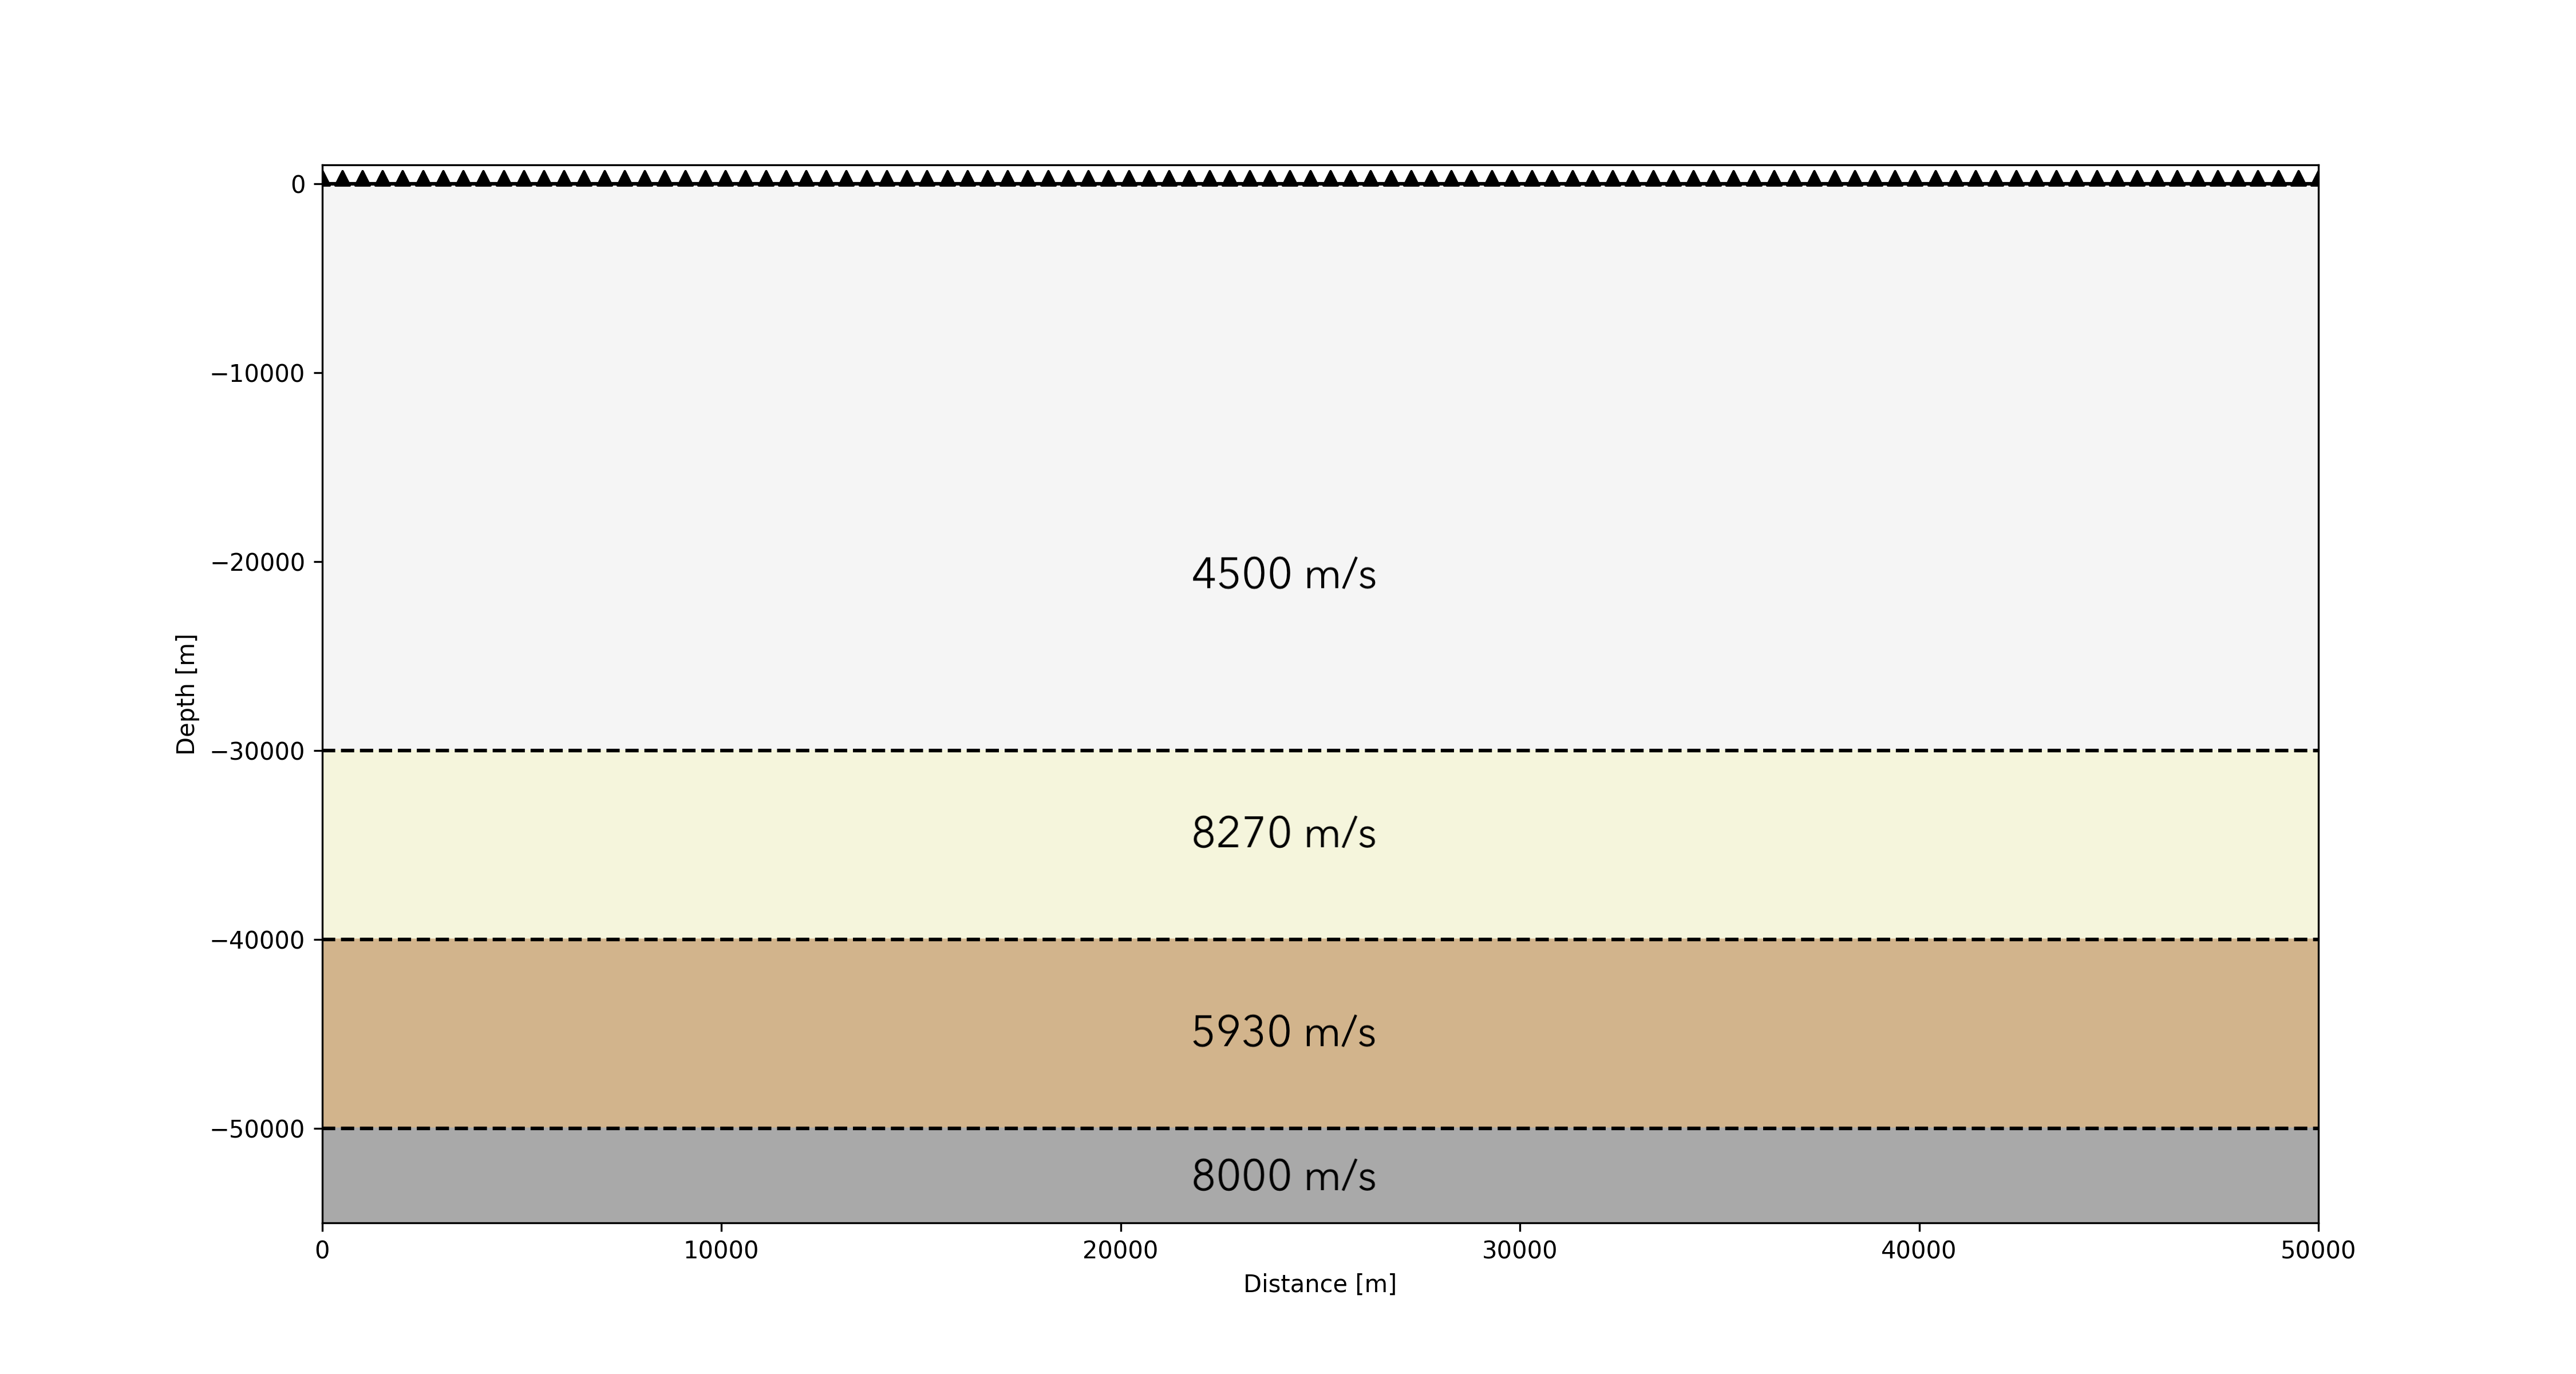

| Rock Type      | P wave velocity (m/s) |
| ---------------| ----------- |
| Sandstone and shale | 2000-4500  |
| Limestone | 2000-6000        |
| Granite   | 5000-6000     |
| Basalt    | 5400-6400      |

_Double-click this cell and replace this text with the answers to Question 3.5. Make sure to address the entire question. Run the cell when you're done._

### **Extra Credit Challenge Question 3.6:** 
Expand on your comments about the validity of the cross section from 3.5 using the figure provided below. 

This figure is a real cross section of the Cascadia Subduction Zone from teleseismic surveys and subsurface models. Note the different depth and distance scales, and that the below figure shows $V_S$, not $V_P$. _(5 points)_
* Where on the below plot might the cross section from 3.5 be located? Indicate using approximate values from the axes of the below plot.
* Do you stand by your assertions from 3.5 about the composition of each layer? Use $V_P / V_S = 1.78$ to again reference the table from 3.5.
* Do you think that the model we used previously showed us anything useful to this problem, having now looked at a real survey?
* Why does the subducting slab disappear after about 80 kilometers "from coast" on this plot?
* Given its location relative to the subduction zone, and your knowledge of Washington geography, what might the red triangle on the plot below represent?

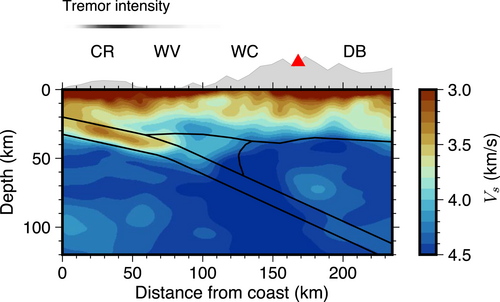
           
**Source:** https://doi.org/10.1029/2022JB025506 (and feel free to take a look at the paper and the other figures in it!)

_Double-click this cell and replace this text with your answers to Question 3.6. Make sure to address every part of the question. Run the cell when you're done._

### **Submission instructions:** 
Make sure you have run **all** cells in your notebook, in order, before saving and submitting, so that all images/graphs appear in the output in your submission. Save the final version of this notebook with your name in the filename and at the beginning (where there is a spot for it). Upload a copy of your notebook and figure for Question 2.4 to Canvas. 

**Please do NOT zip your submissions. Make sure there are NO spaces or wildcard characters in your file names, and that you are submitting the correct file type.** I will not be grading labs that are zipped or have spaces/wildcards in the file names.

This concludes Lab 4. 

_Congrats, you made it!_